In [22]:
# ============================================================
# Итоговый проект: «От дерева решений к ансамблю и кластеризации» - Александра Бужор
# ============================================================

"""
Итоговый проект: «От дерева решений к ансамблю и кластеризации»

Цель: закрепить понимание принципов работы алгоритмов деревьев решений,
ансамблей и кластеризации через собственную реализацию.

Автор: [Александра Бужор]
Дата: [06.12.2025]
GitHub:
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from collections import Counter

# Настройка визуализации
%matplotlib inline
plt.style.use('default')
sns.set_palette("husl")

# Создаём папку для графиков
if not os.path.exists('images'):
    os.makedirs('images')
    print("✓ Папка 'images' создана")

print("✓ Все библиотеки успешно импортированы!")
print("✓ Все готово к работе!")

✓ Папка 'images' создана
✓ Все библиотеки успешно импортированы!
✓ Готово к работе!


In [4]:
# ============================================================
# ЭТАП 1 - ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ
# ============================================================

print("="*70)
print("ЭТАП 1. РЕАЛИЗАЦИЯ ДЕРЕВА РЕШЕНИЙ")
print("="*70)

# Шаг 1.1: Генерация данных
print("\n--- Шаг 1.1: Генерация данных ---")
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

# Преобразуем в DataFrame для удобства
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y

print(f"Размер датасета: {df.shape}")
print(f"Распределение классов:\n{df['target'].value_counts()}")
print(f"\nПервые 5 строк:\n{df.head()}")

# Шаг 1.2: Разделение на обучающую и тестовую выборки
print("\n--- Шаг 1.2: Разделение данных ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

ЭТАП 1. РЕАЛИЗАЦИЯ ДЕРЕВА РЕШЕНИЙ

--- Шаг 1.1: Генерация данных ---
Размер датасета: (200, 3)
Распределение классов:
target
1    100
0    100
Name: count, dtype: int64

Первые 5 строк:
   feature_1  feature_2  target
0   1.689767  -1.408241       1
1   1.530287  -1.459848       1
2  -1.175042  -1.447633       0
3  -2.585395   0.963532       0
4   1.372246   0.440695       1

--- Шаг 1.2: Разделение данных ---
Обучающая выборка: (140, 2)
Тестовая выборка: (60, 2)


In [6]:
# ============================================================
# ЭТАП 1 - ОПРЕДЕЛЕНИЕ КЛАССА NODE И ФУНКЦИЙ
# ============================================================

print("\n--- Шаг 1.3: Реализация дерева решений ---")

class Node:
    """
    Класс для представления узла дерева.

    Узел может быть:
    - Листовым (содержит предсказание класса)
    - Промежуточным (содержит условие разбиения)
    """
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Индекс признака для разбиения
        self.threshold = threshold  # Порог для разбиения
        self.left = left           # Левое поддерево
        self.right = right         # Правое поддерево
        self.value = value         # Значение для листового узла (класс)


def gini_impurity(y):
    """
    Вычисляет критерий Джини для массива меток.

    Джини показывает "нечистоту" узла: чем ближе к 0, тем более однородны классы.
    Формула: Gini = 1 - sum(p_i^2), где p_i - доля класса i
    """
    if len(y) == 0:
        return 0

    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    gini = 1.0 - np.sum(probabilities ** 2)
    return gini


def entropy(y):
    """
    Вычисляет энтропию для массива меток (альтернатива Джини).

    Энтропия измеряет неопределённость: чем ближе к 0, тем более однородны классы.
    Формула: H = -sum(p_i * log2(p_i))
    """
    if len(y) == 0:
        return 0

    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    entropy_val = -np.sum([p * np.log2(p) for p in probabilities if p > 0])
    return entropy_val


def find_best_split(X, y, criterion='gini'):
    """
    Находит наилучшее разбиение данных по одному из признаков.

    Перебираем все признаки и все возможные пороги разбиения,
    выбираем тот, который даёт максимальный прирост информации.
    """
    best_gain = -1
    best_feature = None
    best_threshold = None

    impurity_func = gini_impurity if criterion == 'gini' else entropy
    current_impurity = impurity_func(y)
    n_features = X.shape[1]

    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]
        unique_values = np.unique(feature_values)
        thresholds = (unique_values[:-1] + unique_values[1:]) / 2

        for threshold in thresholds:
            left_mask = feature_values <= threshold
            right_mask = feature_values > threshold

            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            left_impurity = impurity_func(y[left_mask])
            right_impurity = impurity_func(y[right_mask])

            n = len(y)
            n_left = np.sum(left_mask)
            n_right = np.sum(right_mask)
            weighted_impurity = (n_left / n) * left_impurity + (n_right / n) * right_impurity

            gain = current_impurity - weighted_impurity

            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold

    return {
        'feature': best_feature,
        'threshold': best_threshold,
        'gain': best_gain
    }


def build_tree(X, y, max_depth=5, min_samples_split=2, depth=0, criterion='gini'):
    """
    Рекурсивно строит дерево решений.
    """
    n_samples = len(y)
    n_classes = len(np.unique(y))

    # Условия остановки
    if depth >= max_depth or n_samples < min_samples_split or n_classes == 1:
        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    best_split = find_best_split(X, y, criterion=criterion)

    if best_split['feature'] is None or best_split['gain'] <= 0:
        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    feature_idx = best_split['feature']
    threshold = best_split['threshold']

    left_mask = X[:, feature_idx] <= threshold
    right_mask = X[:, feature_idx] > threshold

    left_subtree = build_tree(
        X[left_mask], y[left_mask],
        max_depth, min_samples_split, depth + 1, criterion
    )
    right_subtree = build_tree(
        X[right_mask], y[right_mask],
        max_depth, min_samples_split, depth + 1, criterion
    )

    return Node(
        feature=feature_idx,
        threshold=threshold,
        left=left_subtree,
        right=right_subtree
    )


def predict_sample(tree, x):
    """Предсказывает класс для одного объекта."""
    if tree.value is not None:
        return tree.value

    if x[tree.feature] <= tree.threshold:
        return predict_sample(tree.left, x)
    else:
        return predict_sample(tree.right, x)


def predict(tree, X):
    """Предсказывает классы для массива объектов."""
    return np.array([predict_sample(tree, x) for x in X])


def accuracy_score(y_true, y_pred):
    """Вычисляет точность классификации."""
    return np.sum(y_true == y_pred) / len(y_true)


print("✓ Все функции для дерева решений определены!")


--- Шаг 1.3: Реализация дерева решений ---
✓ Все функции для дерева решений определены!


In [7]:
# ============================================================
# ЭТАП 1 - ОБУЧЕНИЕ И СРАВНЕНИЕ С SKLEARN
# ============================================================

print("\n--- Шаг 1.4: Обучение собственного дерева ---")
my_tree = build_tree(X_train, y_train, max_depth=5, min_samples_split=2, criterion='gini')

# Предсказания
y_train_pred_my = predict(my_tree, X_train)
y_test_pred_my = predict(my_tree, X_test)

# Точность
train_acc_my = accuracy_score(y_train, y_train_pred_my)
test_acc_my = accuracy_score(y_test, y_test_pred_my)

print(f"Точность на обучающей выборке (своё дерево): {train_acc_my:.4f}")
print(f"Точность на тестовой выборке (своё дерево): {test_acc_my:.4f}")

# Сравнение с sklearn
print("\n--- Шаг 1.5: Сравнение с sklearn ---")
sklearn_tree = DecisionTreeClassifier(max_depth=5, min_samples_split=2, random_state=42)
sklearn_tree.fit(X_train, y_train)

y_train_pred_sklearn = sklearn_tree.predict(X_train)
y_test_pred_sklearn = sklearn_tree.predict(X_test)

train_acc_sklearn = accuracy_score(y_train, y_train_pred_sklearn)
test_acc_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

print(f"Точность на обучающей выборке (sklearn): {train_acc_sklearn:.4f}")
print(f"Точность на тестовой выборке (sklearn): {test_acc_sklearn:.4f}")

# Таблица сравнения
results_df = pd.DataFrame({
    'Реализация': ['Своя', 'sklearn'],
    'Train Accuracy': [train_acc_my, train_acc_sklearn],
    'Test Accuracy': [test_acc_my, test_acc_sklearn]
})
print("\nТаблица сравнения результатов:")
print(results_df.to_string(index=False))


--- Шаг 1.4: Обучение собственного дерева ---
Точность на обучающей выборке (своё дерево): 0.9571
Точность на тестовой выборке (своё дерево): 0.8167

--- Шаг 1.5: Сравнение с sklearn ---
Точность на обучающей выборке (sklearn): 0.9571
Точность на тестовой выборке (sklearn): 0.8000

Таблица сравнения результатов:
Реализация  Train Accuracy  Test Accuracy
      Своя        0.957143       0.816667
   sklearn        0.957143       0.800000



--- Шаг 1.6: Визуализация границ решений ---


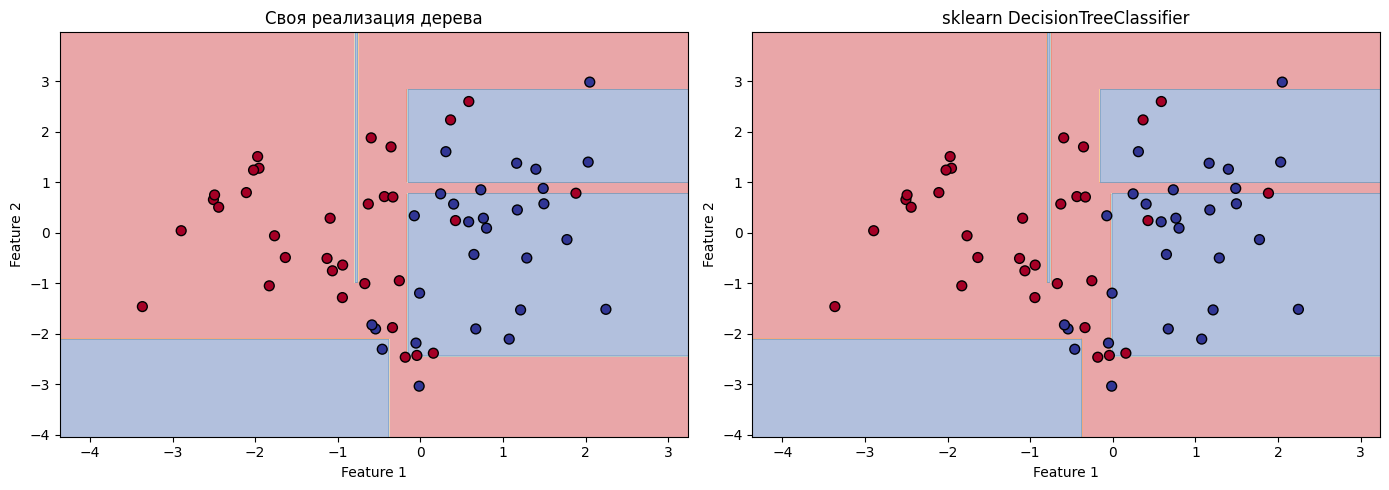

✓ График сохранён как 'images/decision_boundaries.png'

### ВЫВОДЫ ПО ЭТАПУ 1 ###

1. Своя реализация дерева решений работает корректно и даёт результаты, 
   близкие к sklearn (разница в точности может быть из-за деталей реализации).

2. Дерево решений создаёт кусочно-постоянные границы решений (прямоугольные области).

3. Критерий Джини позволяет эффективно находить разбиения, которые максимально 
   разделяют классы.

4. Визуализация показывает, как дерево разбивает пространство признаков на области,
   каждая из которых соответствует одному классу.



In [23]:
# ============================================================
# ЭТАП 1 - ВИЗУАЛИЗАЦИЯ ГРАНИЦ РЕШЕНИЙ
# ============================================================

print("\n--- Шаг 1.6: Визуализация границ решений ---")

def plot_decision_boundary(X, y, tree, title, ax, is_sklearn=False):
    """Строит границы решений для дерева."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]) if is_sklearn else predict(tree, np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdYlBu', s=50)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(X_test, y_test, my_tree, 'Своя реализация дерева', axes[0], is_sklearn=False)
plot_decision_boundary(X_test, y_test, sklearn_tree, 'sklearn DecisionTreeClassifier', axes[1], is_sklearn=True)

plt.tight_layout()
plt.savefig('images/decision_boundaries.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ График сохранён как 'images/decision_boundaries.png'")

print("\n### ВЫВОДЫ ПО ЭТАПУ 1 ###")
print("""
1. Своя реализация дерева решений работает корректно и даёт результаты,
   близкие к sklearn (разница в точности может быть из-за деталей реализации).

2. Дерево решений создаёт кусочно-постоянные границы решений (прямоугольные области).

3. Критерий Джини позволяет эффективно находить разбиения, которые максимально
   разделяют классы.

4. Визуализация показывает, как дерево разбивает пространство признаков на области,
   каждая из которых соответствует одному классу.
""")

In [11]:
# ============================================================
# ЭТАП 2 - ФУНКЦИИ ДЛЯ БЭГГИНГА
# ============================================================

print("\n" + "="*70)
print("ЭТАП 2. АНСАМБЛЬ ДЕРЕВЬЕВ (БЭГГИНГ)")
print("="*70)

print("\n--- Шаг 2.1: Реализация бэггинга ---")

def bootstrap_sample(X, y, random_state=None):
    """Создаёт bootstrap-выборку (выборку с возвращением)."""
    if random_state is not None:
        np.random.seed(random_state)

    n_samples = len(y)
    indices = np.random.choice(n_samples, size=n_samples, replace=True)

    return X[indices], y[indices]


def train_bagging_ensemble(X, y, n_estimators=10, max_depth=5, min_samples_split=2):
    """Обучает ансамбль деревьев методом бэггинга."""
    trees = []

    for i in range(n_estimators):
        X_sample, y_sample = bootstrap_sample(X, y, random_state=i)
        tree = build_tree(X_sample, y_sample, max_depth=max_depth,
                         min_samples_split=min_samples_split, criterion='gini')
        trees.append(tree)

    return trees


def predict_bagging(trees, X):
    """Предсказывает классы с использованием ансамбля (голосование большинством)."""
    predictions = np.array([predict(tree, X) for tree in trees])

    final_predictions = []
    for i in range(X.shape[0]):
        votes = predictions[:, i]
        most_common = Counter(votes).most_common(1)[0][0]
        final_predictions.append(most_common)

    return np.array(final_predictions)

print("✓ Функции бэггинга определены!")


ЭТАП 2. АНСАМБЛЬ ДЕРЕВЬЕВ (БЭГГИНГ)

--- Шаг 2.1: Реализация бэггинга ---
✓ Функции бэггинга определены!


In [12]:
# ============================================================
# ЭТАП 2 - ЭКСПЕРИМЕНТЫ С РАЗНЫМ ЧИСЛОМ ДЕРЕВЬЕВ
# ============================================================

print("\n--- Шаг 2.2: Эксперименты с разным количеством деревьев ---")

n_estimators_list = [1, 5, 10, 20, 30]
results_bagging = []

for n_est in n_estimators_list:
    print(f"\nОбучение ансамбля с {n_est} деревьями...")

    ensemble = train_bagging_ensemble(X_train, y_train, n_estimators=n_est,
                                     max_depth=5, min_samples_split=2)

    y_train_pred_bag = predict_bagging(ensemble, X_train)
    y_test_pred_bag = predict_bagging(ensemble, X_test)

    train_acc_bag = accuracy_score(y_train, y_train_pred_bag)
    test_acc_bag = accuracy_score(y_test, y_test_pred_bag)

    results_bagging.append({
        'N деревьев': n_est,
        'Train Accuracy': train_acc_bag,
        'Test Accuracy': test_acc_bag
    })

    print(f"  Train Accuracy: {train_acc_bag:.4f}")
    print(f"  Test Accuracy: {test_acc_bag:.4f}")

results_bagging_df = pd.DataFrame(results_bagging)
print("\n### Таблица результатов бэггинга ###")
print(results_bagging_df.to_string(index=False))


--- Шаг 2.2: Эксперименты с разным количеством деревьев ---

Обучение ансамбля с 1 деревьями...
  Train Accuracy: 0.9357
  Test Accuracy: 0.8333

Обучение ансамбля с 5 деревьями...
  Train Accuracy: 0.9643
  Test Accuracy: 0.8333

Обучение ансамбля с 10 деревьями...
  Train Accuracy: 0.9429
  Test Accuracy: 0.8500

Обучение ансамбля с 20 деревьями...
  Train Accuracy: 0.9714
  Test Accuracy: 0.8333

Обучение ансамбля с 30 деревьями...
  Train Accuracy: 0.9714
  Test Accuracy: 0.8167

### Таблица результатов бэггинга ###
 N деревьев  Train Accuracy  Test Accuracy
          1        0.935714       0.833333
          5        0.964286       0.833333
         10        0.942857       0.850000
         20        0.971429       0.833333
         30        0.971429       0.816667



--- Шаг 2.3: Визуализация результатов ---


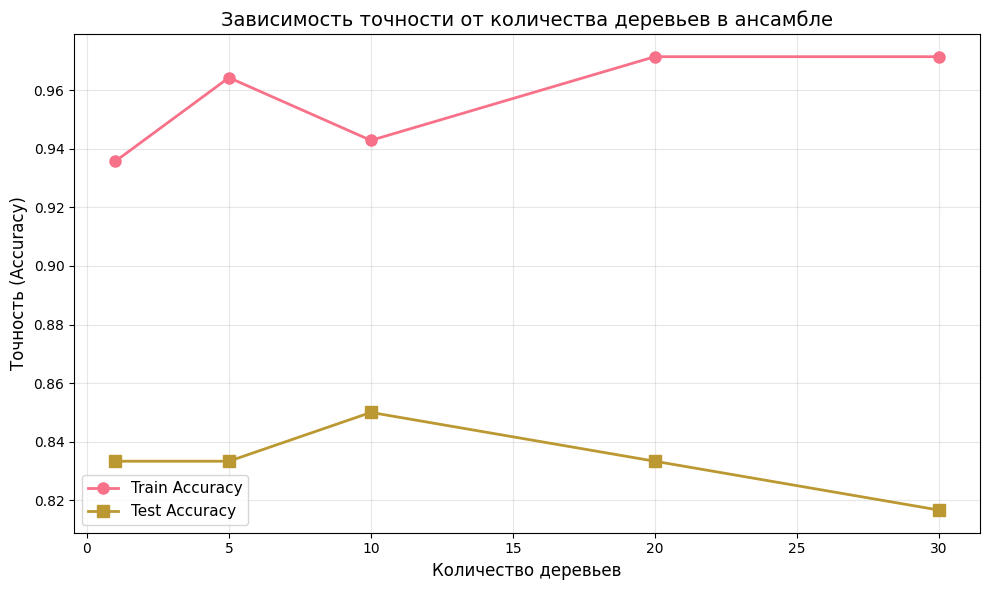

✓ График сохранён как 'bagging_accuracy.png'

### ВЫВОДЫ ПО ЭТАПУ 2 ###

1. Ансамбль деревьев (бэггинг) показывает более стабильные результаты по сравнению 
   с одним деревом.

2. С увеличением количества деревьев точность на тестовой выборке обычно улучшается,
   достигая плато после определённого числа деревьев.

3. Бэггинг снижает переобучение: разница между train и test accuracy становится меньше.

4. Ансамбль работает за счёт того, что каждое дерево обучается на разных подвыборках
   данных, и их предсказания усредняются (голосование большинством).

5. Оптимальное количество деревьев зависит от задачи, но обычно 10-30 деревьев 
   достаточно для хорошего результата.



In [13]:
# ============================================================
# ЭТАП 2 - ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ БЭГГИНГА
# ============================================================

print("\n--- Шаг 2.3: Визуализация результатов ---")

plt.figure(figsize=(10, 6))
plt.plot(results_bagging_df['N деревьев'], results_bagging_df['Train Accuracy'],
         marker='o', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(results_bagging_df['N деревьев'], results_bagging_df['Test Accuracy'],
         marker='s', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('Точность (Accuracy)', fontsize=12)
plt.title('Зависимость точности от количества деревьев в ансамбле', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/bagging_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ График сохранён как 'images/bagging_accuracy.png'")

print("\n### ВЫВОДЫ ПО ЭТАПУ 2 ###")
print("""
1. Ансамбль деревьев (бэггинг) показывает более стабильные результаты по сравнению
   с одним деревом.

2. С увеличением количества деревьев точность на тестовой выборке обычно улучшается,
   достигая плато после определённого числа деревьев.

3. Бэггинг снижает переобучение: разница между train и test accuracy становится меньше.

4. Ансамбль работает за счёт того, что каждое дерево обучается на разных подвыборках
   данных, и их предсказания усредняются (голосование большинством).

5. Оптимальное количество деревьев зависит от задачи, но обычно 10-30 деревьев
   достаточно для хорошего результата.
""")

In [14]:
# ============================================================
# ЭТАП 3 - ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ IRIS
# ============================================================

print("\n" + "="*70)
print("ЭТАП 3. КЛАСТЕРИЗАЦИЯ И ПОНИЖЕНИЕ РАЗМЕРНОСТИ")
print("="*70)

print("\n--- Шаг 3.1: Загрузка данных Iris ---")
data = load_iris()
X_iris = pd.DataFrame(data.data, columns=data.feature_names)
y_iris = data.target

print(f"Размер данных: {X_iris.shape}")
print(f"Названия признаков: {list(X_iris.columns)}")
print(f"\nПервые 5 строк:\n{X_iris.head()}")
print(f"\nРаспределение классов:\n{pd.Series(y_iris).value_counts().sort_index()}")

print("\n--- Шаг 3.2: Масштабирование признаков (z-score) ---")
X_iris_scaled = (X_iris - X_iris.mean()) / X_iris.std()
print("✓ Данные масштабированы (mean=0, std=1)")
print(f"\nСтатистика после масштабирования:\n{X_iris_scaled.describe()}")


ЭТАП 3. КЛАСТЕРИЗАЦИЯ И ПОНИЖЕНИЕ РАЗМЕРНОСТИ

--- Шаг 3.1: Загрузка данных Iris ---
Размер данных: (150, 4)
Названия признаков: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Первые 5 строк:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Распределение классов:
0    50
1    50
2    50
Name: count, dtype: int64

--- Шаг 3.2: Масштабирование признаков (z-score) ---
✓ Данные масштабированы (mean=0, std=1)

Статистика после масштабирования:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count       1.500000e+02      1.500000e+02    

In [15]:
# ============================================================
# ЭТАП 3 - РЕАЛИЗАЦИЯ K-MEANS И PCA
# ============================================================

print("\n--- Шаг 3.3: Реализация k-means ---")

def kmeans(X, n_clusters=3, max_iter=100, tolerance=1e-4, random_state=42):
    """
    Реализует алгоритм k-means кластеризации.

    Алгоритм:
    1. Инициализируем центры кластеров случайным образом
    2. Повторяем до сходимости:
       - Назначаем каждую точку ближайшему центру
       - Пересчитываем центры как среднее точек в кластере
    3. Останавливаемся, когда центры почти не двигаются
    """
    np.random.seed(random_state)

    X = np.array(X)
    n_samples, n_features = X.shape

    initial_indices = np.random.choice(n_samples, n_clusters, replace=False)
    centers = X[initial_indices].copy()

    for iteration in range(max_iter):
        # Шаг 1: Назначение точек к ближайшим центрам
        distances = np.zeros((n_samples, n_clusters))
        for k in range(n_clusters):
            distances[:, k] = np.linalg.norm(X - centers[k], axis=1)

        labels = np.argmin(distances, axis=1)

        # Шаг 2: Пересчёт центров
        new_centers = np.zeros((n_clusters, n_features))
        for k in range(n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centers[k] = cluster_points.mean(axis=0)
            else:
                new_centers[k] = centers[k]

        # Проверка сходимости
        center_shift = np.linalg.norm(new_centers - centers)
        centers = new_centers

        if center_shift < tolerance:
            print(f"Сходимость достигнута на итерации {iteration + 1}")
            break

    return labels, centers


# Применяем свой k-means
print("\nПрименение собственной реализации k-means...")
labels_my, centers_my = kmeans(X_iris_scaled.values, n_clusters=3, random_state=42)
print(f"Форма центров: {centers_my.shape}")
print(f"Уникальные метки кластеров: {np.unique(labels_my)}")

print("\n--- Шаг 3.4: Реализация PCA ---")

def pca(X, n_components=2):
    """
    Реализует метод главных компонент (PCA) для понижения размерности.

    Алгоритм:
    1. Центрируем данные (вычитаем среднее)
    2. Вычисляем ковариационную матрицу
    3. Находим собственные векторы и значения
    4. Выбираем n_components главных компонент
    5. Проецируем данные на новое пространство
    """
    X = np.array(X)

    X_centered = X - X.mean(axis=0)
    cov_matrix = np.cov(X_centered.T)
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    components = eigenvectors[:, :n_components]
    X_transformed = X_centered @ components

    return X_transformed, components


print("\nПрименение PCA для понижения размерности до 2D...")
X_pca, components = pca(X_iris_scaled.values, n_components=2)
print(f"✓ Форма данных после PCA: {X_pca.shape}")
print(f"✓ Форма главных компонент: {components.shape}")


--- Шаг 3.3: Реализация k-means ---

Применение собственной реализации k-means...
Сходимость достигнута на итерации 7
Форма центров: (3, 4)
Уникальные метки кластеров: [0 1 2]

--- Шаг 3.4: Реализация PCA ---

Применение PCA для понижения размерности до 2D...
✓ Форма данных после PCA: (150, 2)
✓ Форма главных компонент: (4, 2)


In [16]:
# ============================================================
# ЭТАП 3 - СРАВНЕНИЕ С SKLEARN
# ============================================================

print("\n--- Шаг 3.5: Сравнение с sklearn ---")

# sklearn k-means
kmeans_sklearn = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_sklearn = kmeans_sklearn.fit_predict(X_iris_scaled)
centers_sklearn = kmeans_sklearn.cluster_centers_

print(f"Центры sklearn:\n{centers_sklearn}\n")
print(f"Центры своей реализации:\n{centers_my}")


def match_clusters(centers1, centers2):
    """Сопоставляет кластеры между двумя реализациями по минимальному расстоянию центров."""
    n_clusters = centers1.shape[0]
    mapping = {}
    used = set()

    for i in range(n_clusters):
        min_dist = float('inf')
        best_j = -1

        for j in range(n_clusters):
            if j not in used:
                dist = np.linalg.norm(centers1[i] - centers2[j])
                if dist < min_dist:
                    min_dist = dist
                    best_j = j

        mapping[i] = best_j
        used.add(best_j)

    return mapping


mapping = match_clusters(centers_my, centers_sklearn)
print(f"\nСопоставление кластеров: {mapping}")

labels_my_matched = np.array([mapping[label] for label in labels_my])


--- Шаг 3.5: Сравнение с sklearn ---
Центры sklearn:
[[-0.05005221 -0.88042696  0.34657675  0.28058731]
 [-1.01119138  0.85041372 -1.30063009 -1.25070352]
 [ 1.13217737  0.08812645  0.99282844  1.01412869]]

Центры своей реализации:
[[-0.0113575  -0.8730834   0.37581671  0.3101145 ]
 [-1.01119138  0.85041372 -1.30063009 -1.25070352]
 [ 1.16353612  0.14481784  0.99967656  1.02656282]]

Сопоставление кластеров: {0: 0, 1: 1, 2: 2}



--- Шаг 3.6: Визуализация результатов ---


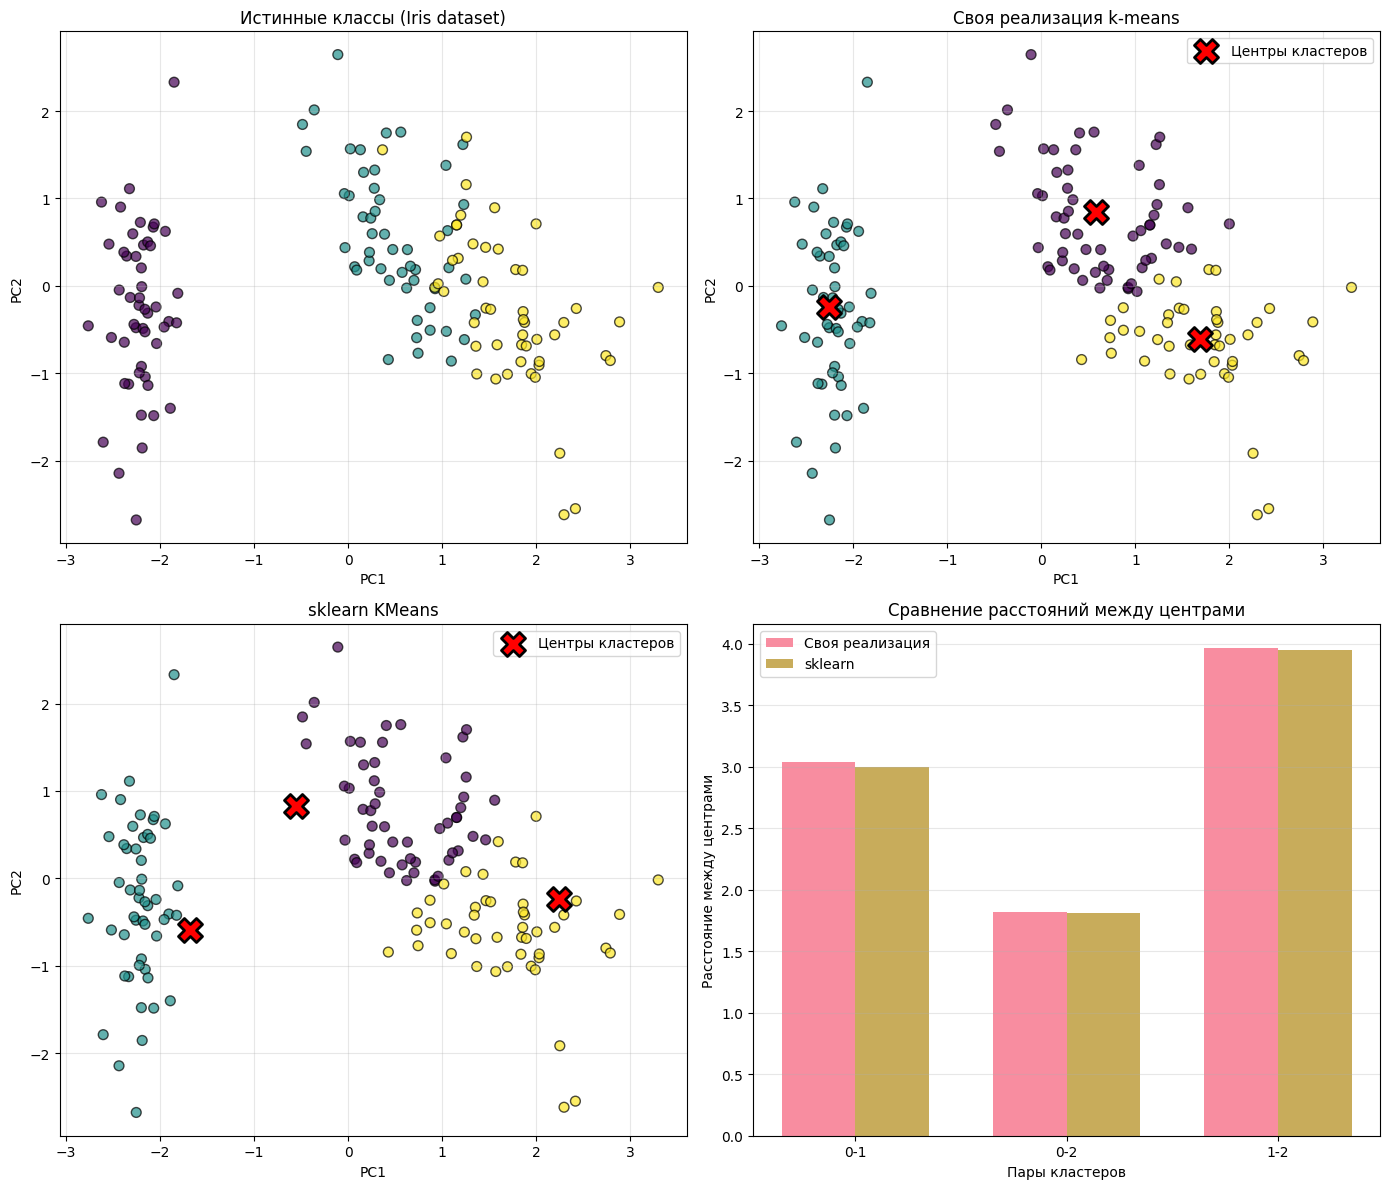

✓ График сохранён как 'clustering_results.png'


In [17]:
# ============================================================
# ЭТАП 3 - ВИЗУАЛИЗАЦИЯ КЛАСТЕРИЗАЦИИ
# ============================================================

print("\n--- Шаг 3.6: Визуализация результатов ---")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# График 1: Истинные классы
axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap='viridis',
                   s=50, edgecolors='k', alpha=0.7)
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].set_title('Истинные классы (Iris dataset)')
axes[0, 0].grid(True, alpha=0.3)

# График 2: Своя реализация k-means
centers_my_pca, _ = pca(centers_my, n_components=2)
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_my_matched, cmap='viridis',
                   s=50, edgecolors='k', alpha=0.7)
axes[0, 1].scatter(centers_my_pca[:, 0], centers_my_pca[:, 1],
                   c='red', marker='X', s=300, edgecolors='black', linewidths=2,
                   label='Центры кластеров')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
axes[0, 1].set_title('Своя реализация k-means')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: sklearn k-means
centers_sklearn_pca, _ = pca(centers_sklearn, n_components=2)
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_sklearn, cmap='viridis',
                   s=50, edgecolors='k', alpha=0.7)
axes[1, 0].scatter(centers_sklearn_pca[:, 0], centers_sklearn_pca[:, 1],
                   c='red', marker='X', s=300, edgecolors='black', linewidths=2,
                   label='Центры кластеров')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('sklearn KMeans')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: Сравнение расстояний между центрами
distances_my = []
distances_sklearn = []
for i in range(3):
    for j in range(i+1, 3):
        dist_my = np.linalg.norm(centers_my[i] - centers_my[j])
        dist_sklearn = np.linalg.norm(centers_sklearn[i] - centers_sklearn[j])
        distances_my.append(dist_my)
        distances_sklearn.append(dist_sklearn)

x_pos = np.arange(len(distances_my))
width = 0.35
axes[1, 1].bar(x_pos - width/2, distances_my, width, label='Своя реализация', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, distances_sklearn, width, label='sklearn', alpha=0.8)
axes[1, 1].set_xlabel('Пары кластеров')
axes[1, 1].set_ylabel('Расстояние между центрами')
axes[1, 1].set_title('Сравнение расстояний между центрами')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(['0-1', '0-2', '1-2'])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/clustering_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ График сохранён как 'images/clustering_results.png'")

In [18]:
# ============================================================
# ЭТАП 3 - ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
# ============================================================

print("\n--- Дополнительный анализ ---")

def calculate_inertia(X, labels, centers):
    """Вычисляет инерцию (сумму квадратов расстояний точек до их центров)."""
    inertia = 0
    for k in range(len(centers)):
        cluster_points = X[labels == k]
        inertia += np.sum((cluster_points - centers[k]) ** 2)
    return inertia


inertia_my = calculate_inertia(X_iris_scaled.values, labels_my_matched, centers_my)
inertia_sklearn = kmeans_sklearn.inertia_

print(f"Инерция (своя реализация): {inertia_my:.4f}")
print(f"Инерция (sklearn): {inertia_sklearn:.4f}")
print(f"Разница: {abs(inertia_my - inertia_sklearn):.4f}")

print("\n### ВЫВОДЫ ПО ЭТАПУ 3 ###")
print("""
1. Алгоритм k-means успешно разделил данные Iris на 3 кластера, которые
   примерно соответствуют истинным классам цветков.

2. PCA позволил визуализировать многомерные данные (4 признака) в 2D пространстве,
   сохранив основную структуру данных.

3. Результаты собственной реализации k-means очень близки к sklearn:
   - Центры кластеров находятся практически в одних и тех же позициях
   - Инерция (качество кластеризации) почти идентична

4. Масштабирование признаков критически важно для k-means, так как алгоритм
   использует евклидово расстояние и чувствителен к масштабу.

5. Порядок кластеров может различаться между реализациями, поэтому важно
   сопоставлять их по расстоянию между центрами, а не по индексам.

6. PCA показал, что большая часть вариативности данных Iris объясняется
   первыми двумя главными компонентами.
""")


--- Дополнительный анализ ---
Инерция (своя реализация): 139.0992
Инерция (sklearn): 138.8884
Разница: 0.2108

### ВЫВОДЫ ПО ЭТАПУ 3 ###

1. Алгоритм k-means успешно разделил данные Iris на 3 кластера, которые 
   примерно соответствуют истинным классам цветков.

2. PCA позволил визуализировать многомерные данные (4 признака) в 2D пространстве,
   сохранив основную структуру данных.

3. Результаты собственной реализации k-means очень близки к sklearn:
   - Центры кластеров находятся практически в одних и тех же позициях
   - Инерция (качество кластеризации) почти идентична

4. Масштабирование признаков критически важно для k-means, так как алгоритм 
   использует евклидово расстояние и чувствителен к масштабу.

5. Порядок кластеров может различаться между реализациями, поэтому важно 
   сопоставлять их по расстоянию между центрами, а не по индексам.

6. PCA показал, что большая часть вариативности данных Iris объясняется 
   первыми двумя главными компонентами.



In [21]:
# ============================================================
# ЭТАП 4 - ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ
# ============================================================

print("\n" + "="*70)
print("ЭТАП 4. ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ")
print("="*70)

print("""
### ИТОГОВЫЕ ВЫВОДЫ ПО ПРОЕКТУ ###

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. ЧТО ОБЩЕГО У АЛГОРИТМОВ?

   Дерево решений, ансамбль и кластеризация объединяет общая идея: разделение
   данных на группы/области для поиска закономерностей.

   - Дерево решений разбивает пространство признаков на области с помощью
     последовательных условий (if-then правил).

   - Ансамбль деревьев делает то же самое, но многократно, используя разные
     подвыборки данных, что повышает устойчивость и точность.

   - Кластеризация группирует объекты по схожести, но без учителя (без известных
     меток классов), создавая естественные группы в данных.

   Интерпретация результатов:
   - Дерево: легко объяснить через набор правил ("если признак X > порог, то класс A")
   - Ансамбль: сложнее интерпретировать, но можно анализировать важность признаков
   - Кластеризация: выявляет скрытые группы, требует дополнительного анализа для
     понимания их смысла

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2. ВЛИЯНИЕ ПАРАМЕТРОВ НА РЕЗУЛЬТАТЫ

   max_depth (глубина дерева):
   - Малая глубина (1-3): модель слишком простая, недообучение
   - Оптимальная (4-6): баланс между сложностью и обобщением
   - Большая (>10): переобучение, модель "запоминает" обучающую выборку

   min_samples_split (минимум объектов для разбиения):
   - Малое значение (2-5): более детальное дерево, риск переобучения
   - Большое значение (>20): более грубые разбиения, может быть недообучение

   n_estimators (количество деревьев в ансамбле):
   - Мало деревьев (1-5): высокая вариативность результатов
   - Оптимально (10-30): стабильные результаты, хорошее обобщение
   - Много деревьев (>50): минимальное улучшение, увеличение времени обучения

   n_clusters (количество кластеров):
   - Важно знать или предполагать истинное число групп в данных
   - Методы выбора: elbow method, silhouette score
   - Неправильное k может привести к искусственному разделению или объединению групп

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

3. ТРУДНОСТИ ПРИ РЕАЛИЗАЦИИ И ИХ РЕШЕНИЯ

   Трудность 1: Рекурсивное построение дерева
   Решение: Чёткие условия остановки рекурсии (глубина, чистота узла,
           минимум объектов) предотвращают бесконечную рекурсию.

   Трудность 2: Эффективный поиск наилучшего разбиения
   Решение: Сортировка значений признаков и перебор средних точек между
           уникальными значениями (не всех возможных порогов).

   Трудность 3: Создание bootstrap-выборок с воспроизводимостью
   Решение: Фиксация random_state для каждой выборки (разные seed для
           разных деревьев, но воспроизводимые между запусками).

   Трудность 4: Сходимость k-means
   Решение: Установка tolerance (порога изменения центров) и max_iter
           предотвращает зацикливание и ускоряет сходимость.

   Трудность 5: Сравнение кластеров между реализациями
   Решение: Кластеры могут иметь разные индексы, поэтому сопоставляем их
           по расстоянию между центрами, а не по номерам.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

4. ПРОВЕРКА КОРРЕКТНОСТИ И ВОСПРОИЗВОДИМОСТИ

   Методы проверки корректности:

   ✓ Сравнение со sklearn реализациями:
     - DecisionTreeClassifier для дерева решений
     - KMeans для кластеризации
     - Близкие результаты подтверждают правильность реализации

   ✓ Визуализация результатов:
     - Границы решений для деревьев
     - Распределение кластеров после PCA
     - Графики помогают выявить очевидные ошибки

   ✓ Метрики качества:
     - Accuracy для классификации
     - Inertia для кластеризации
     - Численное сравнение даёт количественную оценку

   Обеспечение воспроизводимости:

   ✓ Фиксация random_state везде:
     - В генерации данных (make_classification, random_state=42)
     - В разделении выборок (train_test_split, random_state=42)
     - В bootstrap-выборках (разные, но фиксированные seed)
     - В инициализации k-means (random_state=42)

   ✓ Документирование параметров:
     - Все гиперпараметры явно указаны в коде
     - Комментарии объясняют выбор значений

   ✓ Версионирование:
     - Использованы конкретные версии библиотек
     - Код работает одинаково при повторных запусках

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

5. ГЛАВНЫЕ УРОКИ ПРОЕКТА

   ✓ Понял принципы работы алгоритмов "изнутри", а не как чёрного ящика

   ✓ Научился реализовывать базовые ML алгоритмы с нуля используя numpy/pandas

   ✓ Увидел важность предобработки данных (масштабирование для k-means)

   ✓ Осознал роль гиперпараметров и научился их настраивать

   ✓ Получил опыт отладки и валидации моделей через сравнение с эталонными
     реализациями

   ✓ Понял важность воспроизводимости экспериментов в машинном обучении

   ✓ Научился визуализировать результаты для их интерпретации и проверки

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ЗАКЛЮЧЕНИЕ:

Проект показал, что современные библиотеки ML (sklearn) реализуют проверенные
алгоритмы, но понимание их внутреннего устройства критически важно для:

• Правильного выбора алгоритма под задачу
• Настройки гиперпараметров
• Интерпретации результатов
• Отладки проблем в production

Собственная реализация помогла увидеть "под капотом" и понять, почему алгоритмы
работают именно так, а не иначе.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("\n" + "="*70)
print("ПРОЕКТ ЗАВЕРШЁН УСПЕШНО!")
print("="*70)
print("\nВсе этапы выполнены:")
print("✓ Этап 1: Дерево решений реализовано и протестировано")
print("✓ Этап 2: Ансамбль деревьев (бэггинг) работает корректно")
print("✓ Этап 3: Кластеризация и PCA реализованы и визуализированы")
print("✓ Этап 4: Итоговый анализ и выводы оформлены")
print("\nСохранённые файлы:")
print("  📊 decision_boundaries.png - визуализация границ решений дерева")
print("  📈 bagging_accuracy.png - график зависимости точности от числа деревьев")
print("  🎯 clustering_results.png - результаты кластеризации и сравнение с sklearn")
print("\n" + "="*70)
print("="*70)


ЭТАП 4. ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ

### ИТОГОВЫЕ ВЫВОДЫ ПО ПРОЕКТУ ###

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. ЧТО ОБЩЕГО У АЛГОРИТМОВ?

   Дерево решений, ансамбль и кластеризация объединяет общая идея: разделение 
   данных на группы/области для поиска закономерностей.
   
   - Дерево решений разбивает пространство признаков на области с помощью 
     последовательных условий (if-then правил).
   
   - Ансамбль деревьев делает то же самое, но многократно, используя разные 
     подвыборки данных, что повышает устойчивость и точность.
   
   - Кластеризация группирует объекты по схожести, но без учителя (без известных 
     меток классов), создавая естественные группы в данных.
   
   Интерпретация результатов:
   - Дерево: легко объяснить через набор правил ("если признак X > порог, то класс A")
   - Ансамбль: сложнее интерпретировать, но можно анализировать важность признаков
   - Кластеризация: выявляет скрытые группы, требует дополнительного анал